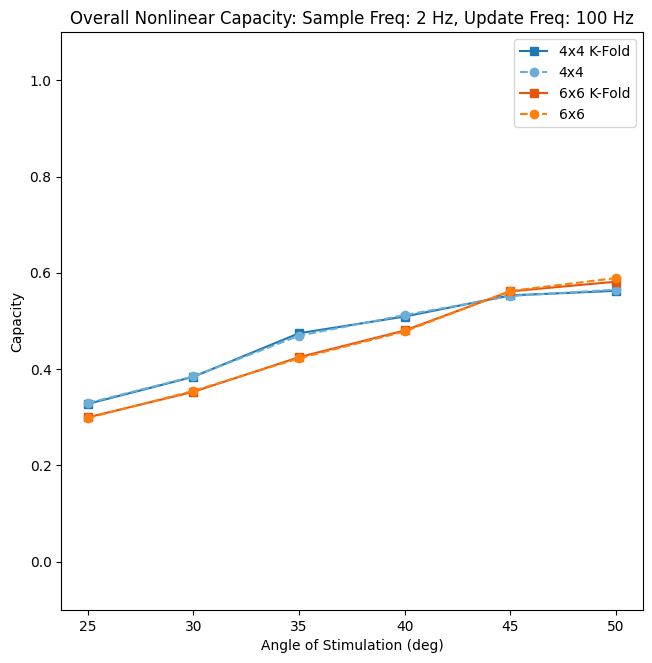

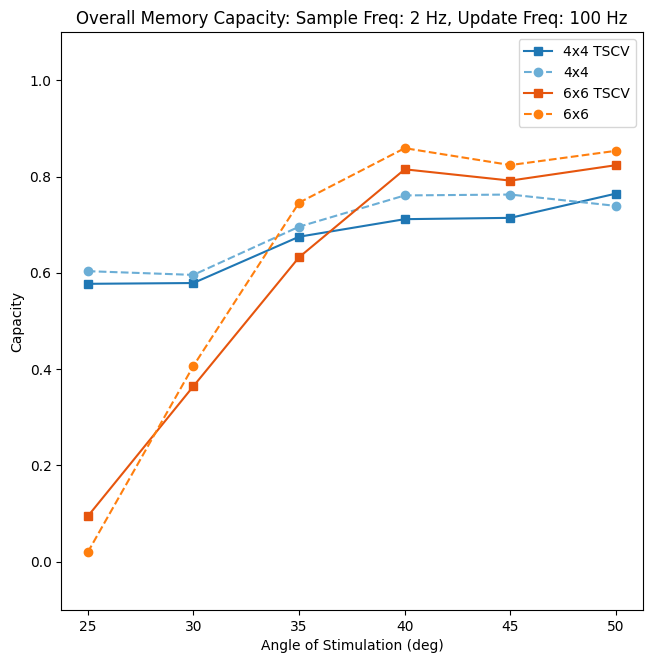

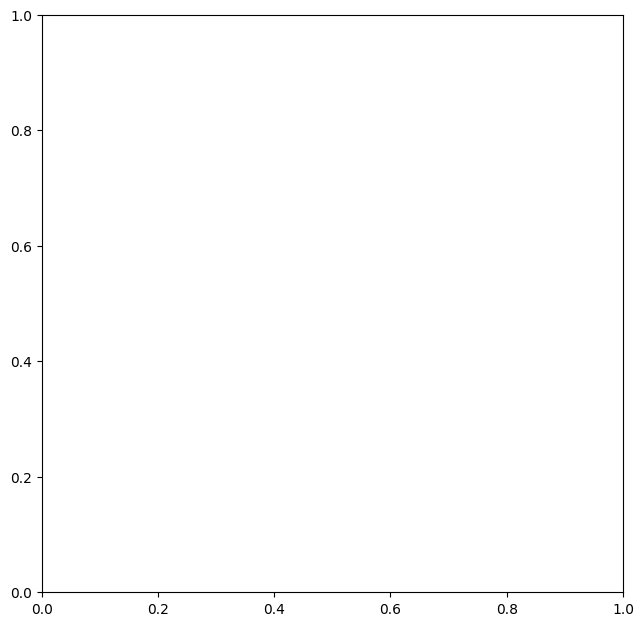

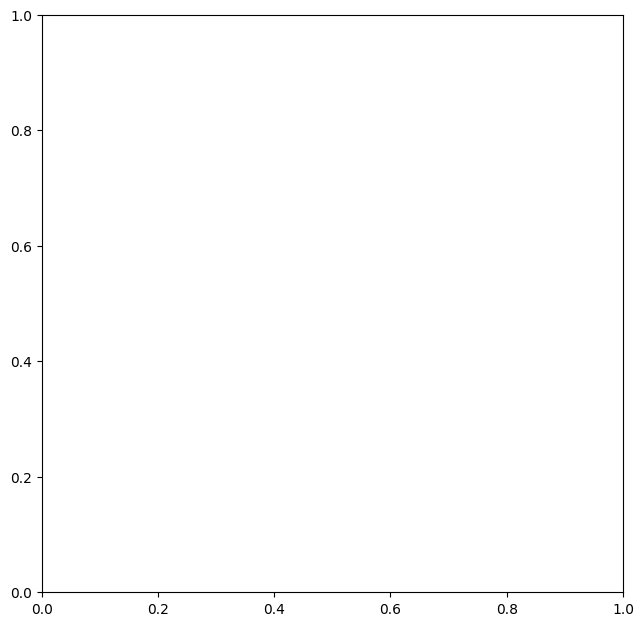

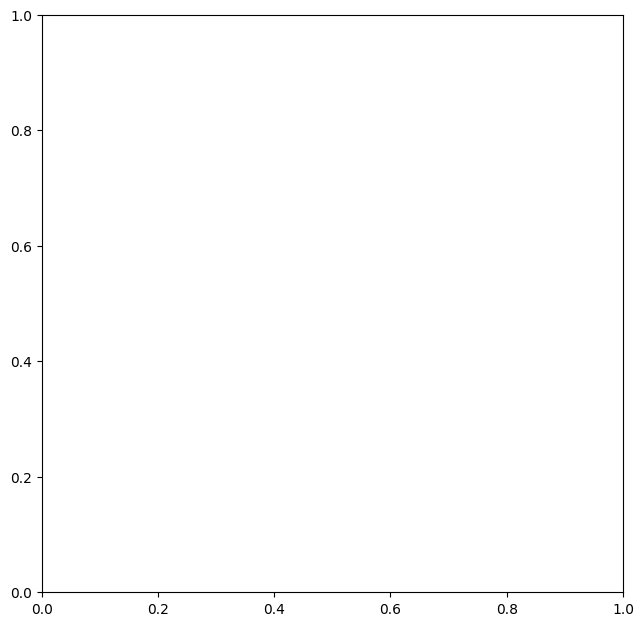

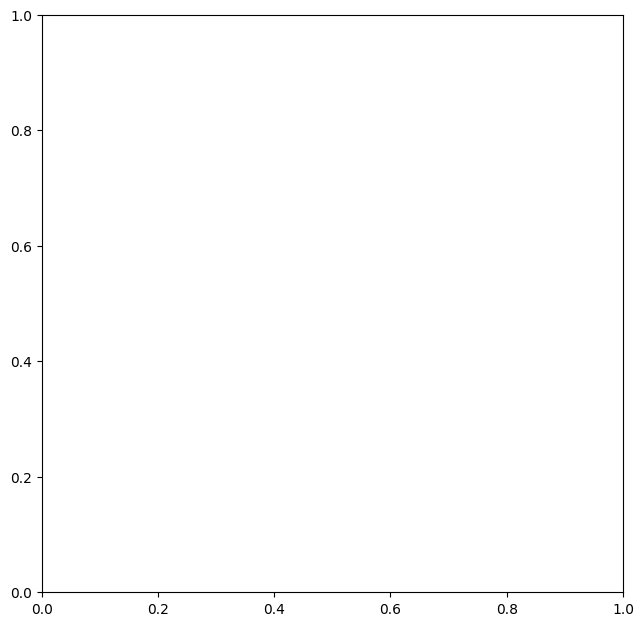

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

save_path = "C:/D/ABHYAAS/OneDrive - Virginia Tech/naughtonlab - active_projects/2025-JIMSS_paper/SI_figures/CV_Experiments"
# save_path = "C:/D/ABHYAAS/OneDrive - Virginia Tech/naughtonlab - Apoorva/BMSLab/Coding/fiber_network_project/fiber_network/Experiments/SAGE/6by6/Videos/corrected"
sample_freq = 2
eval_freq = 100

leg_max_order = 10
max_time_back_seconds = 1
fps = 120
frame_rate_for_img = 1
max_timesteps_back = int(max_time_back_seconds * fps / frame_rate_for_img)
leg_x = np.linspace(1, leg_max_order, leg_max_order)
mem_x = np.linspace(0, max_time_back_seconds, max_timesteps_back+1)

net_size_list = [4, 6]
angle_list = [25, 30, 35, 40, 45, 50]
tab20_colors = ['#1f77b4', '#6baed6', '#e6550d', '#ff7f0e', '#2ca02c', '#74c476', '#d62728', '#d6616b', '#756ab1', '#9e9ac8', '#4a312c', '#8c564b']

fig_onc, ax_onc = plt.subplots(1, 1, figsize=(7.5, 7.5))
fig_omc, ax_omc = plt.subplots(1, 1, figsize=(7.5, 7.5))

for j in range(len(net_size_list)):
    net_size = net_size_list[j]
    color_pairs = [
        (tab20_colors[(2 * i) % len(tab20_colors)], tab20_colors[(2 * i + 1) % len(tab20_colors)])
        for i in range(len(angle_list))
    ]

    class PairColorSelector:
        def __init__(self, pairs, switch_after=4):
            self.pairs = pairs
            self.switch_after = switch_after
            self.call_count = {}

        def __getitem__(self, idx):
            n = self.call_count.get(idx, 0)
            self.call_count[idx] = n + 1
            return self.pairs[idx][0] if n < self.switch_after else self.pairs[idx][1]

    colors_list = PairColorSelector(color_pairs, switch_after=2)

    data_path = f"{net_size}by{net_size}/Videos"

    fig_leg, ax_leg = plt.subplots(1, 1, figsize=(7.5, 7.5))
    fig_mem, ax_mem = plt.subplots(1, 1, figsize=(7.5, 7.5))

    onc_list = []
    omc_list = []
    kf_onc_list = []
    kf_omc_list = []
    tscv_onc_list = []
    tscv_omc_list = []
    for i in range(len(angle_list)):
        angle = angle_list[i]
        eval_data_kfold = np.load(f"{data_path}/{sample_freq}_{eval_freq}_{angle}.MP4_frames/eval_data_10kfold.npz", allow_pickle=True)
        leg_cap = eval_data_kfold['legendre_capacity_test']
        mem_cap = eval_data_kfold['memory_capacity_test']
        # ax_leg.plot(leg_x, leg_cap, '-s', color=colors_list[i], label=f"{angle}° K-Fold")
        # ax_mem.plot(mem_x, mem_cap, '-^', color=colors_list[i], label=f"{angle}° K-Fold")
        kf_onc_list.append(sum(leg_cap)/len(leg_cap))
        kf_omc_list.append(sum(mem_cap)/len(mem_cap))

        eval_data_tscv = np.load(f"{data_path}/{sample_freq}_{eval_freq}_{angle}.MP4_frames/eval_data_10tscv.npz", allow_pickle=True)
        leg_cap = eval_data_tscv['legendre_capacity_test']
        mem_cap = eval_data_tscv['memory_capacity_test']
        # ax_leg.plot(leg_x, leg_cap, '-*', color=colors_list[i], label=f"{angle}° TSCV")
        # ax_mem.plot(mem_x, mem_cap, '-s', color=colors_list[i], label=f"{angle}° TSCV")
        tscv_onc_list.append(sum(leg_cap)/len(leg_cap))
        tscv_omc_list.append(sum(mem_cap)/len(mem_cap))

        eval_data = np.load(f"{data_path}/{sample_freq}_{eval_freq}_{angle}.MP4_frames/eval_data_concat.npz", allow_pickle=True)
        leg_cap = eval_data['legendre_capacity_test']
        mem_cap = eval_data['memory_capacity_test']
        # print(f"Angle: {angle}°, Net Size: {net_size}x{net_size} => Legendre Capacity: {leg_cap} Memory Capacity: {mem_cap}")
        # ax_leg.plot(leg_x, leg_cap, '--o', color=colors_list[i], label=f"{angle}°")
        # ax_mem.plot(mem_x, mem_cap, '--o', color=colors_list[i], label=f"{angle}°")
        onc_list.append(sum(leg_cap)/len(leg_cap))
        omc_list.append(sum(mem_cap)/len(mem_cap))

    # ax_leg.set_title("Nonlinear Performance")
    # ax_leg.set_xlabel("Legendre Polynomial Order")
    # ax_leg.set_ylabel("Capacity")
    # ax_leg.legend()
    # ax_mem.set_title("Memory Capacity")
    # ax_mem.set_xlabel("Recall Time (s)")
    # ax_mem.set_ylabel("Capacity")
    # ax_mem.legend()
    # fig_leg.savefig(f"{save_path}/Legendre_curves_{net_size}by{net_size}_Sample{sample_freq}_Update{eval_freq}_10kfold.pdf", dpi=300)
    # fig_mem.savefig(f"{save_path}/Memory_curves_{net_size}by{net_size}_Sample{sample_freq}_Update{eval_freq}_10tscv.pdf", dpi=300)
    # plt.close(fig_leg)
    # plt.close(fig_mem)

    ax_onc.plot(angle_list, kf_onc_list, '-s', color=colors_list[j], label=f"{net_size}x{net_size} K-Fold")
    ax_omc.plot(angle_list, tscv_omc_list, '-s', color=colors_list[j], label=f"{net_size}x{net_size} TSCV")

    ax_onc.plot(angle_list, onc_list, '--o', color=colors_list[j], label=f"{net_size}x{net_size}")    
    ax_omc.plot(angle_list, omc_list, '--o', color=colors_list[j], label=f"{net_size}x{net_size}")

ax_onc.set_title(f"Overall Nonlinear Capacity: Sample Freq: {sample_freq} Hz, Update Freq: {eval_freq} Hz")
ax_onc.set_xlabel("Angle of Stimulation (deg)")
ax_onc.set_ylabel("Capacity")
ax_onc.set_ylim(-0.1, 1.1)
ax_onc.set_xticks(angle_list)
ax_onc.legend()
fig_onc.savefig(f"{save_path}/Overall_Nonlinearity_Sample{sample_freq}_Update{eval_freq}_10kfold.pdf", dpi=300)
# plt.close(fig_onc)
ax_omc.set_title(f"Overall Memory Capacity: Sample Freq: {sample_freq} Hz, Update Freq: {eval_freq} Hz")
ax_omc.set_xlabel("Angle of Stimulation (deg)")
ax_omc.set_ylabel("Capacity")
ax_omc.set_ylim(-0.1, 1.1)
ax_omc.set_xticks(angle_list)
ax_omc.legend()
fig_omc.savefig(f"{save_path}/Overall_Memory_Sample{sample_freq}_Update{eval_freq}_10tscv.pdf", dpi=300)
# plt.close(fig_omc)   
plt.show() 

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sample_freq = 2
eval_freq = 100

vid_path1 = f"4by4/Videos"
df1 = pd.read_csv(f"{vid_path1}/alpha_grid_search_results_10CV_{sample_freq}_{eval_freq}.csv")
df1['onc_diff'] = df1['onc_train'] - df1['onc_test']
df1['omc_diff'] = df1['omc_train'] - df1['omc_test']
df1['num_threads'] = 4
vid_path2 = f"6by6/Videos"
df2 = pd.read_csv(f"{vid_path2}/alpha_grid_search_results_10CV_{sample_freq}_{eval_freq}.csv")
df2['num_threads'] = 6
df2['onc_diff'] = df2['onc_train'] - df2['onc_test']
df2['omc_diff'] = df2['omc_train'] - df2['omc_test']

df = pd.concat([df1, df2], ignore_index=True)

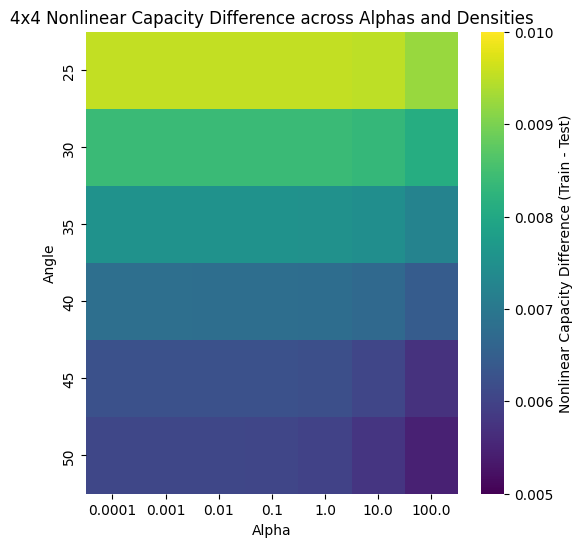

In [14]:
fig1, ax1 = plt.subplots(1, 1, figsize=(6, 6))
heatmap_data = df1.pivot_table(index='angle', columns='alpha', values='onc_diff')
sns.heatmap(heatmap_data, annot=False, cmap='viridis', ax=ax1, cbar_kws={'label': 'Nonlinear Capacity Difference (Train - Test)'}, vmin=0.005, vmax=0.01)
ax1.set_title('4x4 Nonlinear Capacity Difference across Alphas and Densities')
ax1.set_xlabel('Alpha')
ax1.set_ylabel('Angle')
# fig1.savefig(f"{save_path}/Nonlinear_Capacity_Difference_Heatmap_Sample{sample_freq}_Update{eval_freq}.pdf", dpi=300)
plt.show()

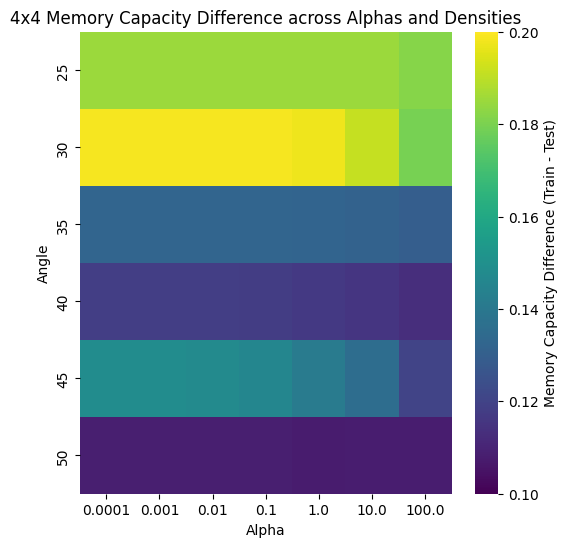

In [15]:
fig2, ax2 = plt.subplots(1, 1, figsize=(6, 6))
heatmap_data = df1.pivot_table(index='angle', columns='alpha', values='omc_diff')
sns.heatmap(heatmap_data, annot=False, cmap='viridis', ax=ax2, cbar_kws={'label': 'Memory Capacity Difference (Train - Test)'}, vmin=0.1, vmax=0.2)
ax2.set_title('4x4 Memory Capacity Difference across Alphas and Densities')
ax2.set_xlabel('Alpha')
ax2.set_ylabel('Angle')
# fig2.savefig(f"{save_path}/Memory_Capacity_Difference_Heatmap_Sample{sample_freq}_Update{eval_freq}.pdf", dpi=300)
plt.show()

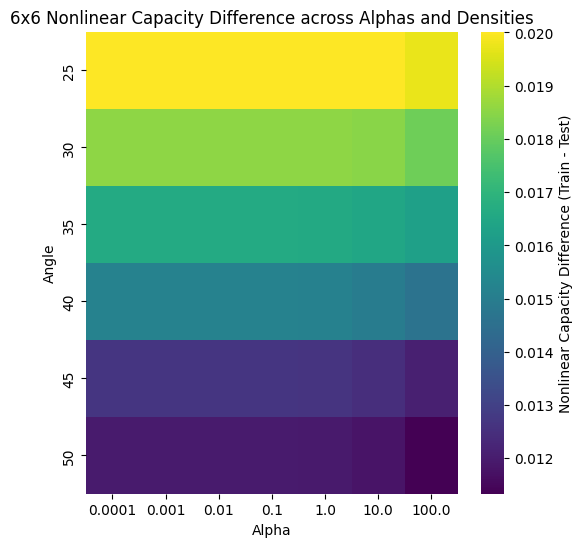

In [18]:
fig3, ax3 = plt.subplots(1, 1, figsize=(6, 6))
heatmap_data = df2.pivot_table(index='angle', columns='alpha', values='onc_diff')
sns.heatmap(heatmap_data, annot=False, cmap='viridis', ax=ax3, cbar_kws={'label': 'Nonlinear Capacity Difference (Train - Test)'})#, vmin=0.005, vmax=0.01)
ax3.set_title('6x6 Nonlinear Capacity Difference across Alphas and Densities')
ax3.set_xlabel('Alpha')
ax3.set_ylabel('Angle')
# fig3.savefig(f"{save_path}/6by6_Nonlinear_Capacity_Difference_Heatmap_Sample{sample_freq}_Update{eval_freq}.pdf", dpi=300)
plt.show()

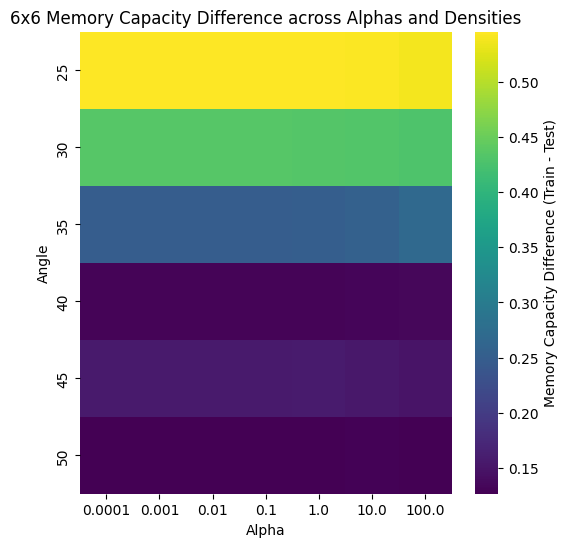

In [19]:
fig4, ax4 = plt.subplots(1, 1, figsize=(6, 6))
heatmap_data = df2.pivot_table(index='angle', columns='alpha', values='omc_diff')
sns.heatmap(heatmap_data, annot=False, cmap='viridis', ax=ax4, cbar_kws={'label': 'Memory Capacity Difference (Train - Test)'})#, vmin=0.14, vmax=0.3)
ax4.set_title('6x6 Memory Capacity Difference across Alphas and Densities')
ax4.set_xlabel('Alpha')
ax4.set_ylabel('Angle')
# fig4.savefig(f"{save_path}/6by6_Memory_Capacity_Difference_Heatmap_Sample{sample_freq}_Update{eval_freq}.pdf", dpi=300)
plt.show()

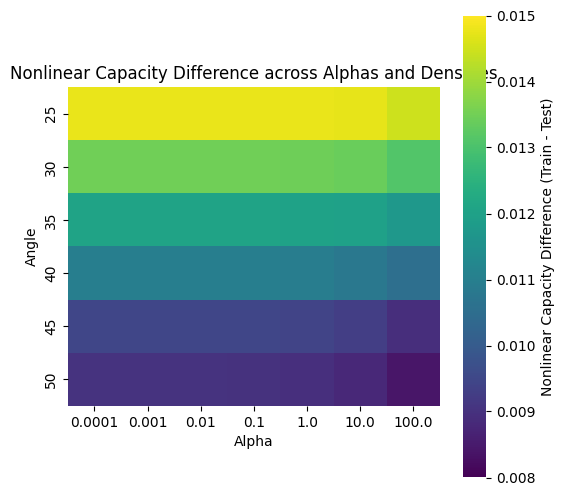

In [3]:
save_path = "C:/D/ABHYAAS/OneDrive - Virginia Tech/naughtonlab - active_projects/2025-JIMSS_paper/SI_figures/CV_Experiments"
fig5, ax5 = plt.subplots(1, 1, figsize=(6, 6))
heatmap_data = df.pivot_table(index='angle', columns='alpha', values='onc_diff')
sns.heatmap(heatmap_data, annot=False, cmap='viridis', ax=ax5, cbar_kws={'label': 'Nonlinear Capacity Difference (Train - Test)'}, vmin=0.008, vmax=0.015, square=True)
ax5.set_title('Nonlinear Capacity Difference across Alphas and Densities')
ax5.set_xlabel('Alpha')
ax5.set_ylabel('Angle')
fig5.savefig(f"{save_path}/Alpha_CV_Nonlinerity_Heatmap_Sample{sample_freq}_Update{eval_freq}.pdf", dpi=300)
plt.show()

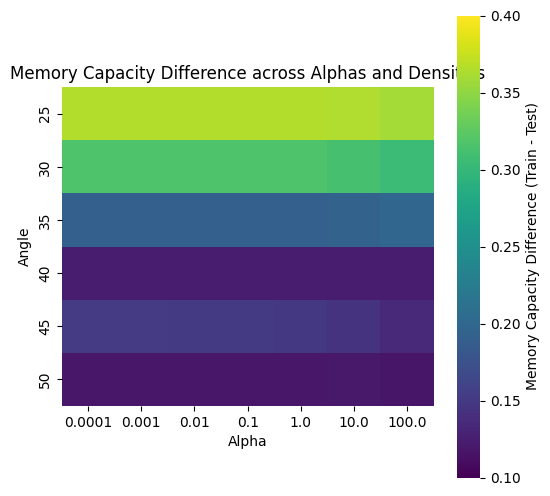

In [4]:
import numpy as np
fig6, ax6 = plt.subplots(1, 1, figsize=(6, 6))
heatmap_data = df.pivot_table(index='angle', columns='alpha', values='omc_diff')
sns.heatmap(heatmap_data, annot=False, cmap='viridis', ax=ax6, cbar_kws={'label': 'Memory Capacity Difference (Train - Test)'}, vmin=0.1, vmax=0.4, square=True)#, vmin=0.125, vmax=0.0375)
ax6.set_title('Memory Capacity Difference across Alphas and Densities')
ax6.set_xlabel('Alpha')
ax6.set_ylabel('Angle')
fig6.savefig(f"{save_path}/Alpha_CV_Memory_Heatmap_Sample{sample_freq}_Update{eval_freq}.pdf", dpi=300)
plt.show()

In [11]:
print(np.round(heatmap_data.max().max(), 2))

0.37


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df1 = pd.read_csv("4by4/Videos/alpha_leg 1 alpha_mem 10/grid_search_results_2_100.csv")
df2 = pd.read_csv("6by6/Videos/alpha_leg 1 alpha_mem 10/grid_search_results_2_100.csv")
df1, df2

(   sample_freq  eval_freq  angle  onc_train  omc_train  onc_test  omc_test
 0            2        100     25   0.337140   0.746880  0.329326  0.603531
 1            2        100     30   0.392729   0.752764  0.384843  0.598010
 2            2        100     35   0.484181   0.791623  0.469340  0.695762
 3            2        100     40   0.515531   0.814888  0.512316  0.761908
 4            2        100     45   0.560198   0.831660  0.551824  0.763491
 5            2        100     50   0.568181   0.859786  0.565240  0.740222,
    sample_freq  eval_freq  angle  onc_train  omc_train  onc_test  omc_test
 0            2        100     25   0.321348   0.540904  0.298280  0.019345
 1            2        100     30   0.372013   0.748044  0.354684  0.406273
 2            2        100     35   0.443419   0.856642  0.422504  0.745523
 3            2        100     40   0.497121   0.937540  0.478206  0.860783
 4            2        100     45   0.574490   0.934740  0.562469  0.820046
 5         

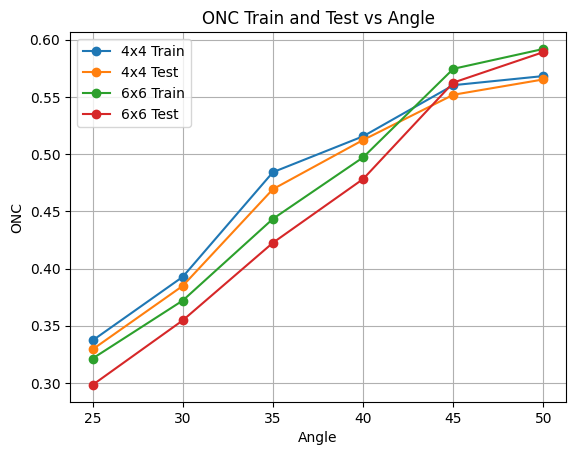

In [2]:
plt.plot(df1['angle'], df1['onc_train'], marker='o', label='4x4 Train')
plt.plot(df1['angle'], df1['onc_test'], marker='o', label='4x4 Test')
plt.plot(df2['angle'], df2['onc_train'], marker='o', label='6x6 Train')
plt.plot(df2['angle'], df2['onc_test'], marker='o', label='6x6 Test')
plt.legend()
plt.xlabel('Angle')
plt.ylabel('ONC')
plt.title('ONC Train and Test vs Angle')
plt.grid(True)
plt.show()

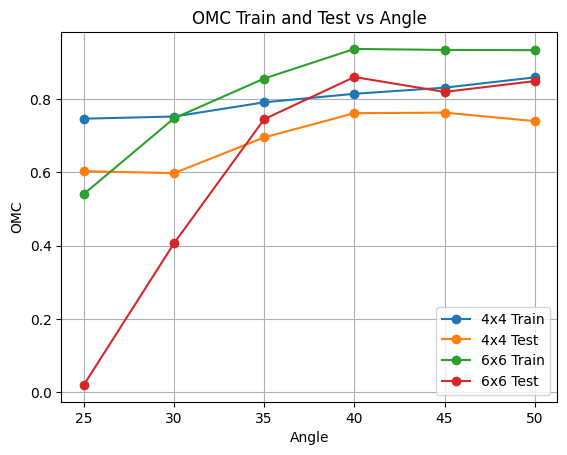

In [3]:
plt.plot(df1['angle'], df1['omc_train'], marker='o', label='4x4 Train')
plt.plot(df1['angle'], df1['omc_test'], marker='o', label='4x4 Test')
plt.plot(df2['angle'], df2['omc_train'], marker='o', label='6x6 Train')
plt.plot(df2['angle'], df2['omc_test'], marker='o', label='6x6 Test')
plt.legend()
plt.xlabel('Angle')
plt.ylabel('OMC')
plt.title('OMC Train and Test vs Angle')
plt.grid(True)
plt.show()

In [4]:
df3 = pd.read_csv("4by4/Videos/narma_performance_2_100_10.csv")
df4 = pd.read_csv("6by6/Videos/narma_performance_2_100_10.csv")
df5 = pd.read_csv("4by4/Videos/narma_performance_2_100_20.csv")
df6 = pd.read_csv("6by6/Videos/narma_performance_2_100_20.csv")
df7 = pd.read_csv("4by4/Videos/narma_performance_2_100_120.csv")
df8 = pd.read_csv("6by6/Videos/narma_performance_2_100_120.csv")

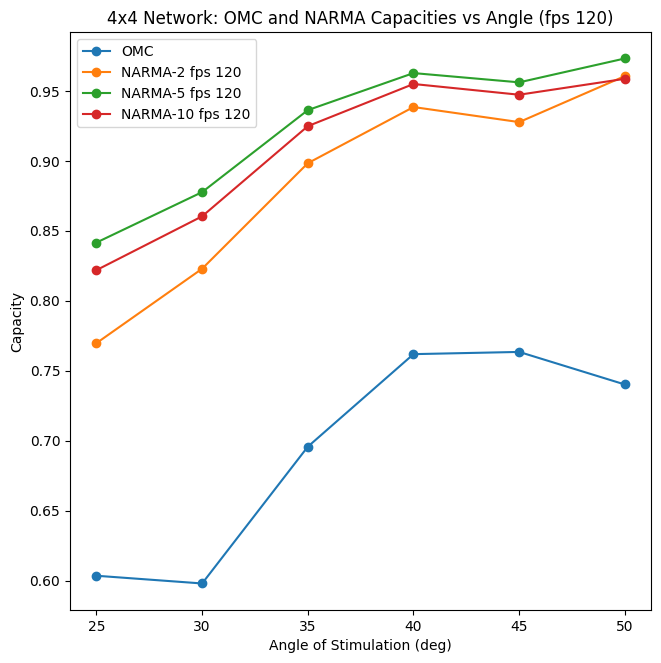

In [7]:
plt.figure(figsize=(7.5, 7.5))
plt.plot(df1['angle'], df1['omc_test'], marker='o', label='OMC')
# for order in [2, 5, 10]:
#     plt.plot(df3['angle'], df3[f'n{order}_cap_test'], marker='o', label=f'NARMA-{order}')
for order in [2, 5, 10]:
    # plt.plot(df3['angle'], df3[f'n{order}_cap_test'], marker='o', label=f'NARMA-{order} fps 10')
    # plt.plot(df5['angle'], df5[f'n{order}_cap_test'], marker='o', label=f'NARMA-{order} fps 20')
    plt.plot(df7['angle'], df7[f'n{order}_cap_test'], marker='o', label=f'NARMA-{order} fps 120')
plt.xlabel('Angle of Stimulation (deg)')
plt.ylabel('Capacity')
plt.legend()
plt.title('4x4 Network: OMC and NARMA Capacities vs Angle (fps 120)')
plt.show()

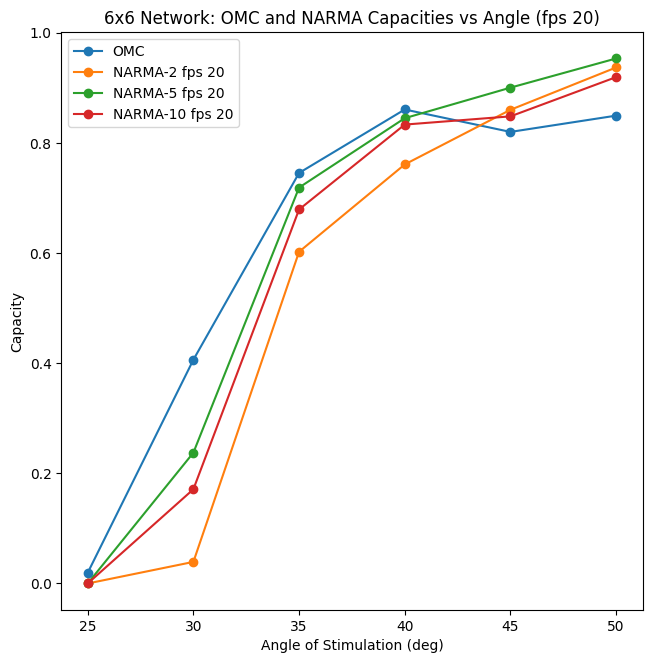

In [9]:
plt.figure(figsize=(7.5, 7.5))
plt.plot(df2['angle'], df2['omc_test'], marker='o', label='OMC')
# for order in [2, 5, 10]:
#     plt.plot(df4['angle'], df4[f'n{order}_cap_test'], marker='o', label=f'NARMA-{order}')
for order in [2, 5, 10]:
    # plt.plot(df4['angle'], df4[f'n{order}_cap_test'], marker='o', label=f'NARMA-{order} fps 10')
    plt.plot(df6['angle'], df6[f'n{order}_cap_test'], marker='o', label=f'NARMA-{order} fps 20')
    # plt.plot(df8['angle'], df8[f'n{order}_cap_test'], marker='o', label=f'NARMA-{order} fps 120')
plt.xlabel('Angle of Stimulation (deg)')
plt.ylabel('Capacity')
plt.legend()
plt.title('6x6 Network: OMC and NARMA Capacities vs Angle (fps 20)')
plt.show()

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

save_path = "C:/D/ABHYAAS/OneDrive - Virginia Tech/naughtonlab - active_projects/2025-JIMSS_paper/pdf_v4/Fig 4"

# df_violin = pd.read_csv("6by6/Videos/narma_violin_data_2_100_10.csv")
# df_violin
narma2_errors = np.load("./6by6/Videos/2_100_50.MP4_frames/narma2_errors.npz", allow_pickle=True)
narma5_errors = np.load("./6by6/Videos/2_100_50.MP4_frames/narma5_errors.npz", allow_pickle=True)
narma10_errors = np.load("./6by6/Videos/2_100_50.MP4_frames/narma10_errors.npz", allow_pickle=True)

n2_ae = narma2_errors['AE']
n2_se = narma2_errors['SE']
n2_e = narma2_errors['E']
n2_ne = narma2_errors['NE']
n5_ae = narma5_errors['AE']
n5_se = narma5_errors['SE']
n5_e = narma5_errors['E']
n5_ne = narma5_errors['NE']
n10_ae = narma10_errors['AE']
n10_se = narma10_errors['SE']
n10_e = narma10_errors['E']
n10_ne = narma10_errors['NE']

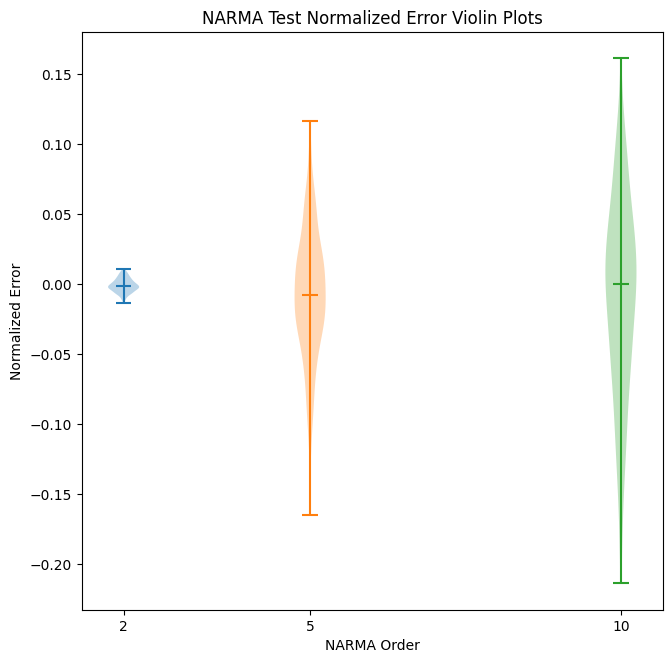

In [20]:
import matplotlib

matplotlib.rc('pdf', fonttype=42)
plt.figure(figsize=(7.5, 7.5))
plt.violinplot(n2_ne, 
               positions=[2], #showmeans=True,
               showmedians=True)
plt.violinplot(n5_ne, 
               positions=[5], #showmeans=True,
               showmedians=True)
plt.violinplot(n10_ne, 
               positions=[10], #showmeans=True,
               showmedians=True)
plt.xlabel("NARMA Order")
plt.ylabel("Normalized Error")
plt.xticks([2, 5, 10])
plt.title("NARMA Test Normalized Error Violin Plots")
plt.savefig(f"{save_path}/NARMA_violin_plots_normalized_error_6by6.pdf", dpi=300)
plt.show()

In [ ]:
n2_rmse = np.sqrt((np.sum(n2_se)/len(n2_se)))
n5_rmse = np.sqrt((np.sum(n5_se)/len(n5_se)))
n10_rmse = np.sqrt((np.sum(n10_se)/len(n10_se)))

n2_interdecile_range_e = np.percentile(n2_e, 90) - np.percentile(n2_e, 10)
n5_interdecile_range_e = np.percentile(n5_e, 90) - np.percentile(n5_e, 10)
n10_interdecile_range_e = np.percentile(n10_e, 90) - np.percentile(n10_e, 10)

n2_interdecile_range_ne = np.percentile(n2_ne, 90) - np.percentile(n2_ne, 10)
n5_interdecile_range_ne = np.percentile(n5_ne, 90) - np.percentile(n5_ne, 10)
n10_interdecile_range_ne = np.percentile(n10_ne, 90) - np.percentile(n10_ne, 10)

print("NARMA-2 RMSE:", n2_rmse)
print("Interdecile Range for E:", n2_interdecile_range_e, "for NE:", n2_interdecile_range_ne)
print("NARMA-5 RMSE:", n5_rmse)
print("Interdecile Range for E:", n5_interdecile_range_e, "for NE:", n5_interdecile_range_ne)
print("NARMA-10 RMSE:", n10_rmse)
print("Interdecile Range for E:", n10_interdecile_range_e, "for NE:", n10_interdecile_range_ne)

NARMA-2 RMSE: 0.0009629966658388338
Interdecile Range for E: 0.002458478540779011 for NE: 0.012574499313243337
NARMA-5 RMSE: 0.009241281765421548
Interdecile Range for E: 0.023830311924744538 for NE: 0.11889131142715714
NARMA-10 RMSE: 0.015724375182695694 Interdecile Range for E: 0.04081819426382179 for NE: 0.1870314632585919
Interdecile Range for E: 0.04081819426382179 for NE: 0.1870314632585919
